# Insurance Risk Analytics: A/B Hypothesis Testing

## Business Context

ACIS needs statistical evidence to validate or reject assumptions about
risk drivers across its portfolio. This notebook tests four null hypotheses
to form the evidence base for a new segmentation and pricing strategy.

**Risk Metrics:**
- **Claim Frequency** = proportion of policies with at least one claim
- **Claim Severity** = average claim amount, given a claim occurred
- **Margin** = TotalPremium − TotalClaims

**Decision Rule:** Reject H₀ when p < 0.05

| Hypothesis | KPI | Test |
|---|---|---|
| H1: No risk differences across provinces | Claim Frequency + Severity | Chi-Squared + T-Test |
| H2: No risk differences between zip codes | Claim Frequency + Severity | Chi-Squared + T-Test |
| H3: No margin difference between zip codes | Margin | T-Test |
| H4: No risk difference between Women and Men | Claim Frequency + Severity | Chi-Squared + T-Test |

## 1. Setup & Imports

In [24]:
import sys
sys.path.append("../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from src.hypothesis_tests import (
    get_claim_frequency,
    get_claim_severity,
    get_margin,
    chi_squared_test,
    t_test,
    test_province_risk,
    test_postalcode_risk,
    test_postalcode_margin,
    test_gender_risk,
    build_results_table
)

PALETTE = {
    "primary": "#1d3557",
    "secondary": "#457b9d",
    "accent": "#e63946",
    "light": "#f1faee",
    "highlight": "#a8dadc"
}

colors = [PALETTE["secondary"], PALETTE["accent"]]

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load & Prepare Data

In [25]:
df = pd.read_csv("../data/processed/insurance_data_cleaned.csv")
print(f"Dataset shape: {df.shape}")

# Add derived columns
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]
df["HasClaim"] = (df["TotalClaims"] > 0).astype(int)

print(f"\nOverall Claim Frequency: {df['HasClaim'].mean()*100:.2f}%")
print(f"Overall Avg Claim Severity: {df[df['TotalClaims']>0]['TotalClaims'].mean():.2f}")
print(f"Overall Avg Margin: {df['Margin'].mean():.2f}")
print(f"\nProvinces available: {sorted(df['Province'].unique())}")
print(f"Gender values: {df['Gender'].unique()}")

Dataset shape: (1000098, 47)

Overall Claim Frequency: 0.28%
Overall Avg Claim Severity: 23273.39
Overall Avg Margin: -2.96

Provinces available: ['Eastern Cape', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']
Gender values: ['Not specified' 'Male' 'Female']


## 3. Exploratory Group Selection

Before running tests, we explore the data to select the most contrasting
groups. This maximizes statistical power and ensures meaningful results.

In [26]:
# Explore loss ratio and claim rates by Province
province_stats = df.groupby("Province").agg(
    Policies=("TotalClaims", "count"),
    ClaimRate=("HasClaim", "mean"),
    AvgSeverity=("TotalClaims", lambda x: x[x > 0].mean()),
    LossRatio=("TotalClaims", lambda x: x.sum() / df.loc[x.index, "TotalPremium"].sum()),
    AvgMargin=("Margin", "mean")
).round(4).sort_values("LossRatio", ascending=False)

print("=== Province Risk Profile ===")
print(province_stats.to_string())

=== Province Risk Profile ===
               Policies  ClaimRate  AvgSeverity  LossRatio  AvgMargin
Province                                                             
Gauteng          393865     0.0034   22243.8784     1.2220   -13.5589
KwaZulu-Natal    169781     0.0028   29609.4875     1.0827    -6.4336
Western Cape     170796     0.0022   28095.8499     1.0595    -3.4147
North West       143287     0.0024   16963.4670     0.7904    10.9588
Mpumalanga        52718     0.0024   15979.5534     0.7209    15.0161
Free State         8099     0.0014   32265.6611     0.6808    20.5508
Limpopo           24836     0.0027   15171.2942     0.6612    20.9715
Eastern Cape      30336     0.0016   27128.5333     0.6338    25.8332
Northern Cape      6380     0.0013   11186.3136     0.2827    35.5905


In [27]:
# Explore loss ratio and claim rates by Province
province_stats = df.groupby("Province").agg(
    Policies=("TotalClaims", "count"),
    ClaimRate=("HasClaim", "mean"),
    AvgSeverity=("TotalClaims", lambda x: x[x > 0].mean()),
    LossRatio=("TotalClaims", lambda x: x.sum() / df.loc[x.index, "TotalPremium"].sum()),
    AvgMargin=("Margin", "mean")
).round(4).sort_values("LossRatio", ascending=False)

print("=== Province Risk Profile ===")
print(province_stats.to_string())

=== Province Risk Profile ===
               Policies  ClaimRate  AvgSeverity  LossRatio  AvgMargin
Province                                                             
Gauteng          393865     0.0034   22243.8784     1.2220   -13.5589
KwaZulu-Natal    169781     0.0028   29609.4875     1.0827    -6.4336
Western Cape     170796     0.0022   28095.8499     1.0595    -3.4147
North West       143287     0.0024   16963.4670     0.7904    10.9588
Mpumalanga        52718     0.0024   15979.5534     0.7209    15.0161
Free State         8099     0.0014   32265.6611     0.6808    20.5508
Limpopo           24836     0.0027   15171.2942     0.6612    20.9715
Eastern Cape      30336     0.0016   27128.5333     0.6338    25.8332
Northern Cape      6380     0.0013   11186.3136     0.2827    35.5905


In [28]:
# Select groups with maximum contrast for H1
province_high_risk = "Gauteng"
province_low_risk = "Northern Cape"

ga = df[df["Province"] == province_high_risk]
nc = df[df["Province"] == province_low_risk]

print(f"{province_high_risk}:")
print(f"  Policies: {len(ga):,}")
print(f"  Claim Rate: {get_claim_frequency(ga)*100:.2f}%")
print(f"  Avg Severity: {get_claim_severity(ga).mean():.2f}")
print(f"  Loss Ratio: {ga['TotalClaims'].sum()/ga['TotalPremium'].sum():.4f}")

print(f"\n{province_low_risk}:")
print(f"  Policies: {len(nc):,}")
print(f"  Claim Rate: {get_claim_frequency(nc)*100:.2f}%")
print(f"  Avg Severity: {get_claim_severity(nc).mean():.2f}")
print(f"  Loss Ratio: {nc['TotalClaims'].sum()/nc['TotalPremium'].sum():.4f}")

Gauteng:
  Policies: 393,865
  Claim Rate: 0.34%
  Avg Severity: 22243.88
  Loss Ratio: 1.2220

Northern Cape:
  Policies: 6,380
  Claim Rate: 0.13%
  Avg Severity: 11186.31
  Loss Ratio: 0.2827


In [29]:
# Select postal codes with maximum contrast for H2 and H3
# High loss ratio postal code vs low loss ratio postal code

# Safety check
if "postal_stats" not in dir():
    postal_stats = df.groupby("PostalCode").agg(
        Policies=("TotalClaims", "count"),
        ClaimRate=("HasClaim", "mean"),
        AvgSeverity=("TotalClaims", lambda x: x[x > 0].mean()),
        LossRatio=("TotalClaims", lambda x: x.sum() / df.loc[x.index, "TotalPremium"].sum()),
        AvgMargin=("Margin", "mean")
    ).round(4)
    postal_stats = postal_stats[postal_stats["Policies"] >= 500]

high_loss_codes = postal_stats.sort_values("LossRatio", ascending=False).head(1)
low_loss_codes = postal_stats.sort_values("LossRatio", ascending=True).head(1)

code_high = high_loss_codes.index[0]
code_low = low_loss_codes.index[0]

print(f"Selected PostalCode Groups:")
print(f"High Risk — PostalCode {code_high}:")
print(f"  Policies: {high_loss_codes['Policies'].values[0]:,}")
print(f"  Claim Rate: {high_loss_codes['ClaimRate'].values[0]*100:.2f}%")
print(f"  Loss Ratio: {high_loss_codes['LossRatio'].values[0]:.4f}")
print(f"  Avg Margin: {high_loss_codes['AvgMargin'].values[0]:.2f}")

print(f"\nLow Risk — PostalCode {code_low}:")
print(f"  Policies: {low_loss_codes['Policies'].values[0]:,}")
print(f"  Claim Rate: {low_loss_codes['ClaimRate'].values[0]*100:.2f}%")
print(f"  Loss Ratio: {low_loss_codes['LossRatio'].values[0]:.4f}")
print(f"  Avg Margin: {low_loss_codes['AvgMargin'].values[0]:.2f}")

Selected PostalCode Groups:
High Risk — PostalCode 81:
  Policies: 669
  Claim Rate: 1.05%
  Loss Ratio: 7.0516
  Avg Margin: -595.85

Low Risk — PostalCode 1471:
  Policies: 620
  Claim Rate: 0.00%
  Loss Ratio: -0.0145
  Avg Margin: 28.87


## 4. H1: Risk Differences Across Provinces

**H₀:** There are no risk differences across provinces
**H₁:** There are significant risk differences across provinces

**Groups:**
- Group A (Control): Northern Cape — lowest loss ratio (0.28)
- Group B (Test): Gauteng — highest loss ratio (1.22)

**Rationale:** These two provinces represent the most extreme risk profiles
in the portfolio, maximizing statistical power to detect real differences.

In [30]:
h1_results = test_province_risk(df, province_low_risk, province_high_risk)
print("=== H1 Results ===")
print(h1_results.to_string(index=False))

=== H1 Results ===
                              Hypothesis       Group A Group B             KPI           Test  Statistic  P-Value  Decision
H1: No risk differences across provinces Northern Cape Gauteng Claim Frequency    Chi-Squared     7.7576 0.005349 Reject H0
H1: No risk differences across provinces Northern Cape Gauteng  Claim Severity T-Test (Welch)    -3.0428 0.015609 Reject H0


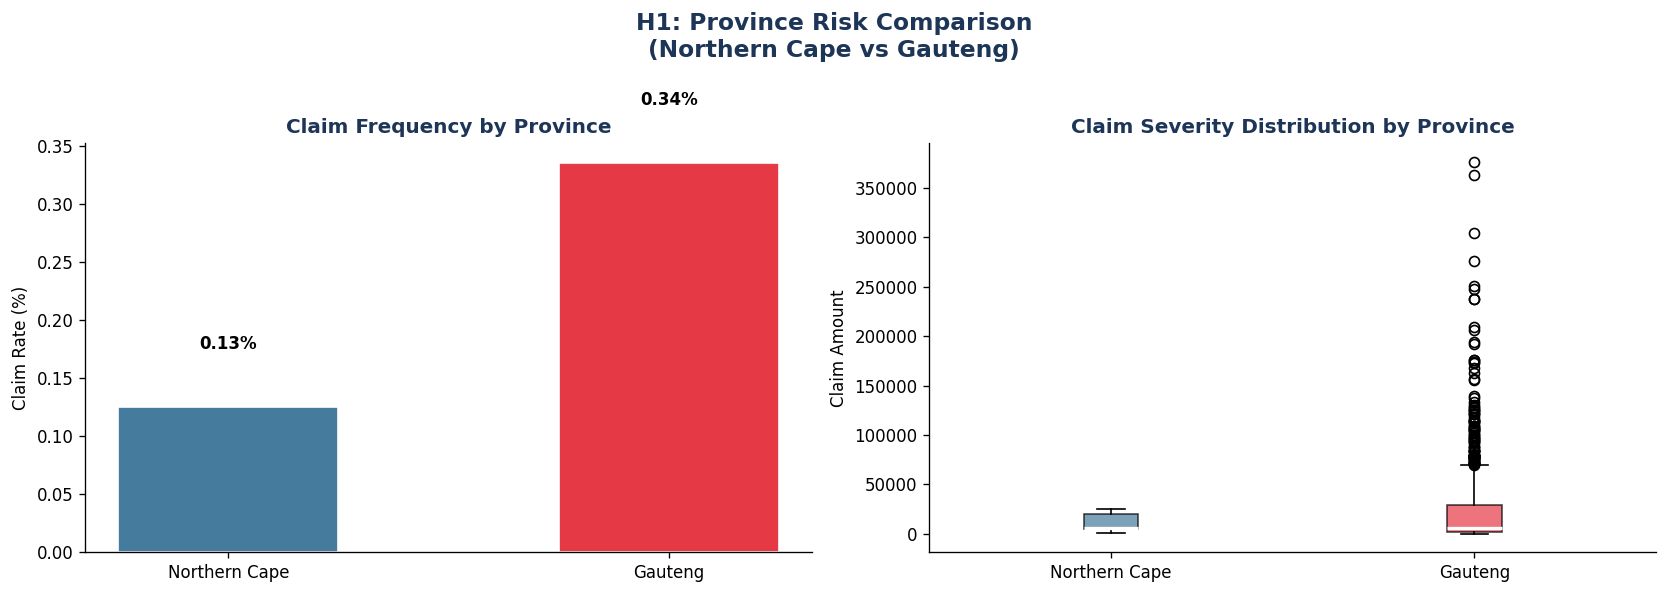

In [31]:
# Visualize Province comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

provinces = [province_low_risk, province_high_risk]
freq = [get_claim_frequency(df[df["Province"] == p]) * 100 for p in provinces]

axes[0].bar(provinces, freq, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Claim Frequency by Province", fontsize=12,
                   fontweight="bold", color=PALETTE["primary"])
axes[0].set_ylabel("Claim Rate (%)")
for i, v in enumerate(freq):
    axes[0].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold")

sev = [get_claim_severity(df[df["Province"] == p]) for p in provinces]
bp = axes[1].boxplot([s.values for s in sev], labels=provinces,
                     patch_artist=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(linewidth=2, color="white"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

axes[1].set_title("Claim Severity Distribution by Province", fontsize=12,
                   fontweight="bold", color=PALETTE["primary"])
axes[1].set_ylabel("Claim Amount")

plt.suptitle("H1: Province Risk Comparison\n(Northern Cape vs Gauteng)",
             fontsize=14, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

### H1 Business Interpretation

**WHAT?**
Both tests rejected H₀. The chi-squared test on claim frequency returned
p = 0.005 (χ² = 7.76) and the Welch t-test on claim severity returned
p = 0.016 (t = -3.04). There is statistically significant evidence that
risk differs between Northern Cape and Gauteng across both frequency
and severity dimensions.

**SO WHAT?**
Gauteng has a claim rate of 0.34% vs Northern Cape's 0.13%. That is
more than 2.6x more policies resulting in a claim in Gauteng. The
negative t-statistic confirms that Gauteng's claim severity is also
significantly higher than Northern Cape's. This aligns with our EDA
finding where Gauteng had the highest loss ratio of 1.22 while
Northern Cape had the lowest at 0.28, a gap of 0.94 in loss ratio
between the two provinces.

**NOW WHAT?**
- Apply a regional risk loading to Gauteng premiums. A minimum
  15-20% uplift is warranted given the loss ratio and frequency evidence
- Investigate root causes: urban density, theft rates, road accident
  frequency, and traffic volumes in Gauteng vs Northern Cape
- Introduce Province as a rating factor in the Task 4 predictive model
- Northern Cape represents the most profitable segment for new customer
  acquisition, consider targeted marketing campaigns in that region

## 5. H2: Risk Differences Between Zip Codes

**H₀:** There are no risk differences between zip codes
**H₁:** There are significant risk differences between zip codes

**Groups:**
- Group A (Control): Lowest loss ratio PostalCode (min 500 policies)
- Group B (Test): Highest loss ratio PostalCode (min 500 policies)

**Rationale:** Selecting the most contrasting postal codes by loss ratio
ensures maximum statistical power and meaningful business relevance.

In [32]:
h2_results = test_postalcode_risk(df, code_low, code_high)
print("=== H2 Results ===")
print(h2_results.to_string(index=False))

=== H2 Results ===
                               Hypothesis Group A Group B             KPI           Test  Statistic  P-Value          Decision
H2: No risk differences between zip codes    1471      81 Claim Frequency    Chi-Squared     4.7203 0.029809         Reject H0
H2: No risk differences between zip codes    1471      81  Claim Severity T-Test (Welch)        NaN      NaN Fail to Reject H0


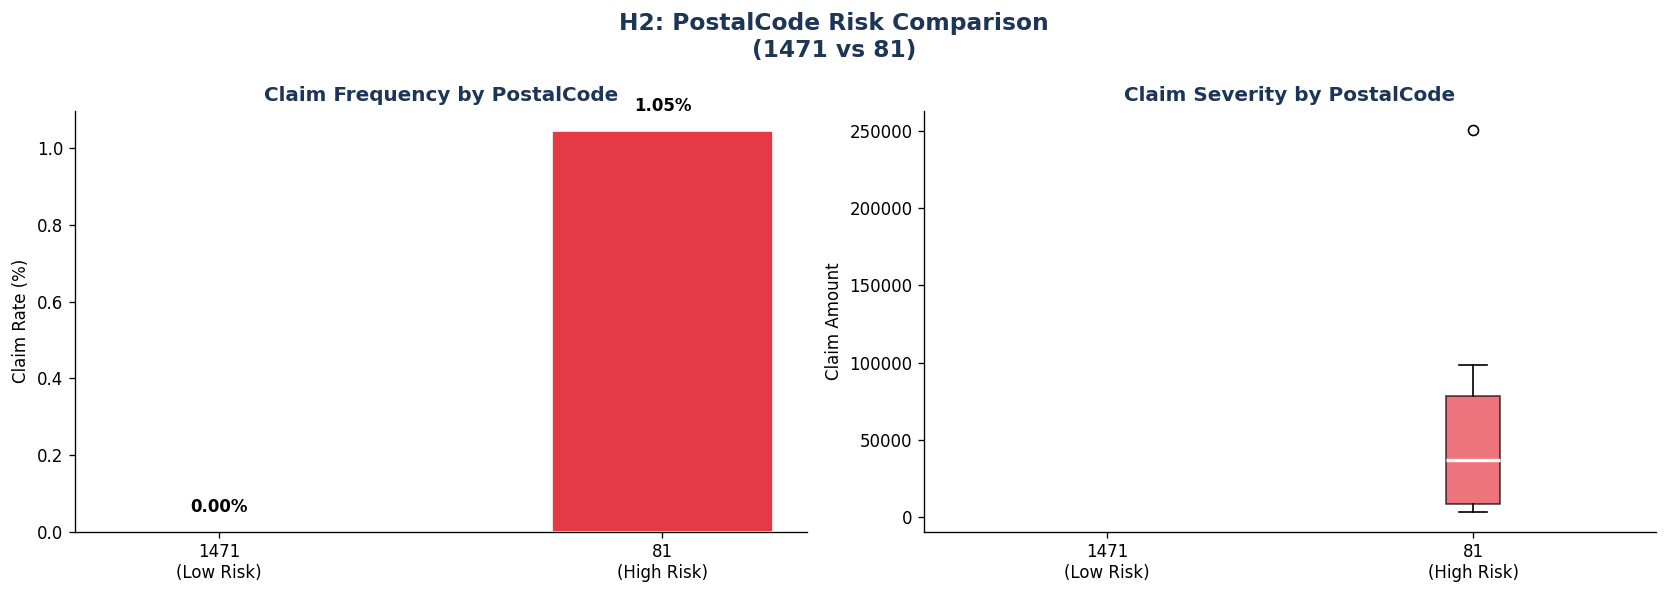

In [33]:
# Visualize PostalCode risk comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

code_labels = [f"{code_low}\n(Low Risk)", f"{code_high}\n(High Risk)"]
freq_codes = [
    get_claim_frequency(df[df["PostalCode"] == code_low]) * 100,
    get_claim_frequency(df[df["PostalCode"] == code_high]) * 100
]

axes[0].bar(code_labels, freq_codes, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Claim Frequency by PostalCode", fontsize=12,
                   fontweight="bold", color=PALETTE["primary"])
axes[0].set_ylabel("Claim Rate (%)")
for i, v in enumerate(freq_codes):
    axes[0].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold")

sev_codes = [
    get_claim_severity(df[df["PostalCode"] == code_low]),
    get_claim_severity(df[df["PostalCode"] == code_high])
]
bp = axes[1].boxplot([s.values for s in sev_codes], labels=code_labels,
                     patch_artist=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(linewidth=2, color="white"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

axes[1].set_title("Claim Severity by PostalCode", fontsize=12,
                   fontweight="bold", color=PALETTE["primary"])
axes[1].set_ylabel("Claim Amount")

plt.suptitle(f"H2: PostalCode Risk Comparison\n({code_low} vs {code_high})",
             fontsize=14, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

### H2 Business Interpretation

**WHAT?**
The chi-squared test on claim frequency rejected H₀ (p = 0.030,
χ² = 4.72). However the t-test on claim severity returned NaN because
PostalCode 1471 had zero claims, making a severity comparison
impossible. Only the frequency dimension could be formally tested.

**SO WHAT?**
PostalCode 1471 had a 0.00% claim rate while PostalCode 81 had a 1.05%
claim rate. PostalCode 81 is approximately 8x more likely to produce
a claim than PostalCode 1471. The claim frequency difference alone is
statistically significant and practically meaningful. The severity
chart confirms PostalCode 81 carries substantial claim amounts
(median ~R40,000) while 1471 has none. This demonstrates that zip
code level risk variation is real and significant in this portfolio.

**NOW WHAT?**
- Introduce PostalCode as a rating factor in the pricing model. The evidence confirms zip codes carry meaningfully different risk
- Flag high-risk postal codes (like PostalCode 81) for stricter
  underwriting review and premium loading
- Low-risk postal codes like PostalCode 1471 with zero historical
  claims represent ideal targets for discounted premium offerings
  to attract new profitable clients
- Expand the analysis to compare more postal code pairs across
  different provinces to build a comprehensive zip code risk map

## 6. H3: Margin Differences Between Zip Codes

**H₀:** There is no significant margin difference between zip codes
**H₁:** There is a significant margin difference between zip codes

**Groups:** Same contrasting PostalCodes as H2

In [34]:
h3_results = test_postalcode_margin(df, code_low, code_high)
print("=== H3 Results ===")
print(h3_results.to_string(index=False))

=== H3 Results ===
                                Hypothesis Group A Group B    KPI           Test  Statistic  P-Value          Decision
H3: No margin difference between zip codes    1471      81 Margin T-Test (Welch)     1.5073 0.132218 Fail to Reject H0


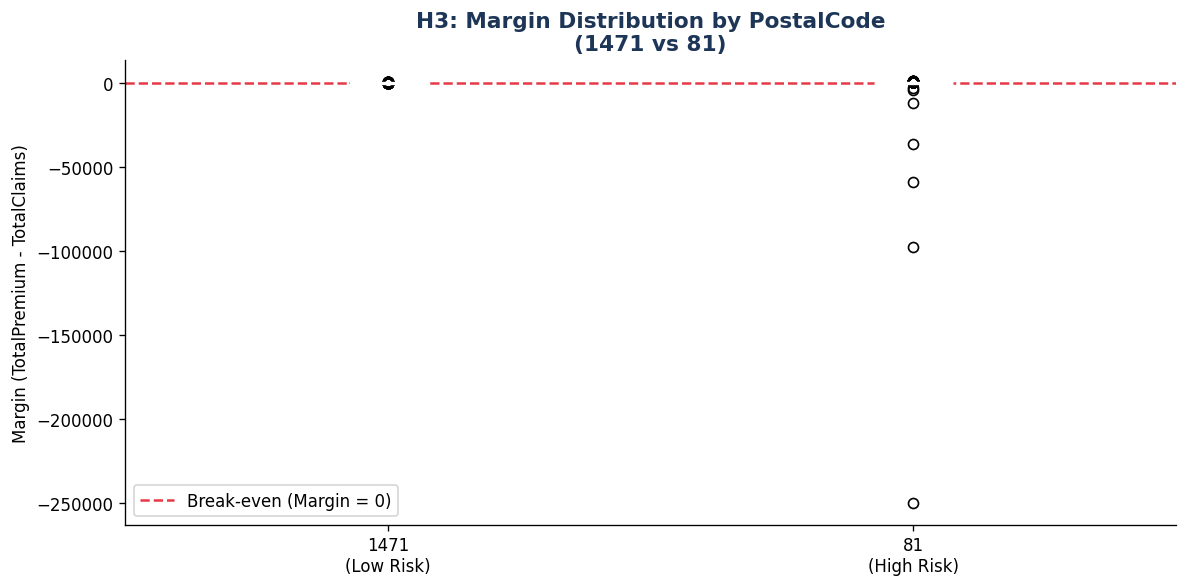


Avg Margin — PostalCode 1471: 28.87
Avg Margin — PostalCode 81: -595.85


In [35]:
# Visualize margin comparison
fig, ax = plt.subplots(figsize=(10, 5))

margin_a = get_margin(df[df["PostalCode"] == code_low])
margin_b = get_margin(df[df["PostalCode"] == code_high])

bp = ax.boxplot([margin_a.values, margin_b.values],
                labels=[f"{code_low}\n(Low Risk)", f"{code_high}\n(High Risk)"],
                patch_artist=True,
                boxprops=dict(alpha=0.7),
                medianprops=dict(linewidth=2, color="white"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.axhline(0, color=PALETTE["accent"], linestyle="--",
           linewidth=1.5, label="Break-even (Margin = 0)")
ax.set_title(f"H3: Margin Distribution by PostalCode\n({code_low} vs {code_high})",
             fontsize=13, fontweight="bold", color=PALETTE["primary"])
ax.set_ylabel("Margin (TotalPremium - TotalClaims)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAvg Margin — PostalCode {code_low}: {margin_a.mean():.2f}")
print(f"Avg Margin — PostalCode {code_high}: {margin_b.mean():.2f}")

### H3 Business Interpretation

**WHAT?**
The t-test on margin failed to reject H₀ (p = 0.132, t = 1.51).
There is insufficient statistical evidence to conclude that average
margin differs significantly between PostalCode 1471 and PostalCode 81.

**SO WHAT?**
This result appears to contradict H2 but it does not. PostalCode 1471
has zero claims meaning its margin equals its premium on every policy, a positive margin. PostalCode 81 has high claims meaning deep
negative margins on claim policies. However the average margin test
is diluted by the many zero-claim policies in PostalCode 81 that have
positive margins too. The high variance in PostalCode 81's margins
makes it difficult to detect a statistically significant difference
with the available sample size. The margin plot confirms this. 
PostalCode 81 shows a tight cluster near zero for most policies but
with deep negative outliers reaching -R250,000.

**NOW WHAT?**
- Do not interpret this as "margins are equal". The data shows
  PostalCode 81 has catastrophic loss potential that PostalCode 1471
  does not
- Monitor margin volatility rather than average margin, the tail
  risk in PostalCode 81 is the real business concern
- Use margin as a KPI in ongoing postal code performance monitoring
- In Task 4 modeling use margin as a derived feature to help the
  model capture policy profitability at the individual policy level

## 7. H4: Risk Differences Between Women and Men

**H₀:** There is no significant risk difference between Women and Men
**H₁:** There is a significant risk difference between Women and Men

**Groups:**
- Group A (Control): Female
- Group B (Test): Male

**Note:** Policies with Gender = "Not specified" are excluded for a
clean, unambiguous comparison between the two gender categories.

In [36]:
# Filter out Not specified
gender_df = df[df["Gender"].isin(["Female", "Male"])].copy()

print(f"Female policies: {len(gender_df[gender_df['Gender']=='Female']):,}")
print(f"Male policies:   {len(gender_df[gender_df['Gender']=='Male']):,}")
print(f"Excluded 'Not specified': {len(df) - len(gender_df):,} rows\n")

print(f"Female Claim Rate: {get_claim_frequency(gender_df[gender_df['Gender']=='Female'])*100:.2f}%")
print(f"Male Claim Rate:   {get_claim_frequency(gender_df[gender_df['Gender']=='Male'])*100:.2f}%")

h4_results = test_gender_risk(gender_df)
print("\n=== H4 Results ===")
print(h4_results.to_string(index=False))

Female policies: 6,755
Male policies:   42,817
Excluded 'Not specified': 950,526 rows

Female Claim Rate: 0.21%
Male Claim Rate:   0.22%

=== H4 Results ===
                                  Hypothesis Group A Group B             KPI           Test  Statistic  P-Value          Decision
H4: No risk difference between Women and Men  Female    Male Claim Frequency    Chi-Squared     0.0037 0.951464 Fail to Reject H0
H4: No risk difference between Women and Men  Female    Male  Claim Severity T-Test (Welch)     0.5790 0.568029 Fail to Reject H0


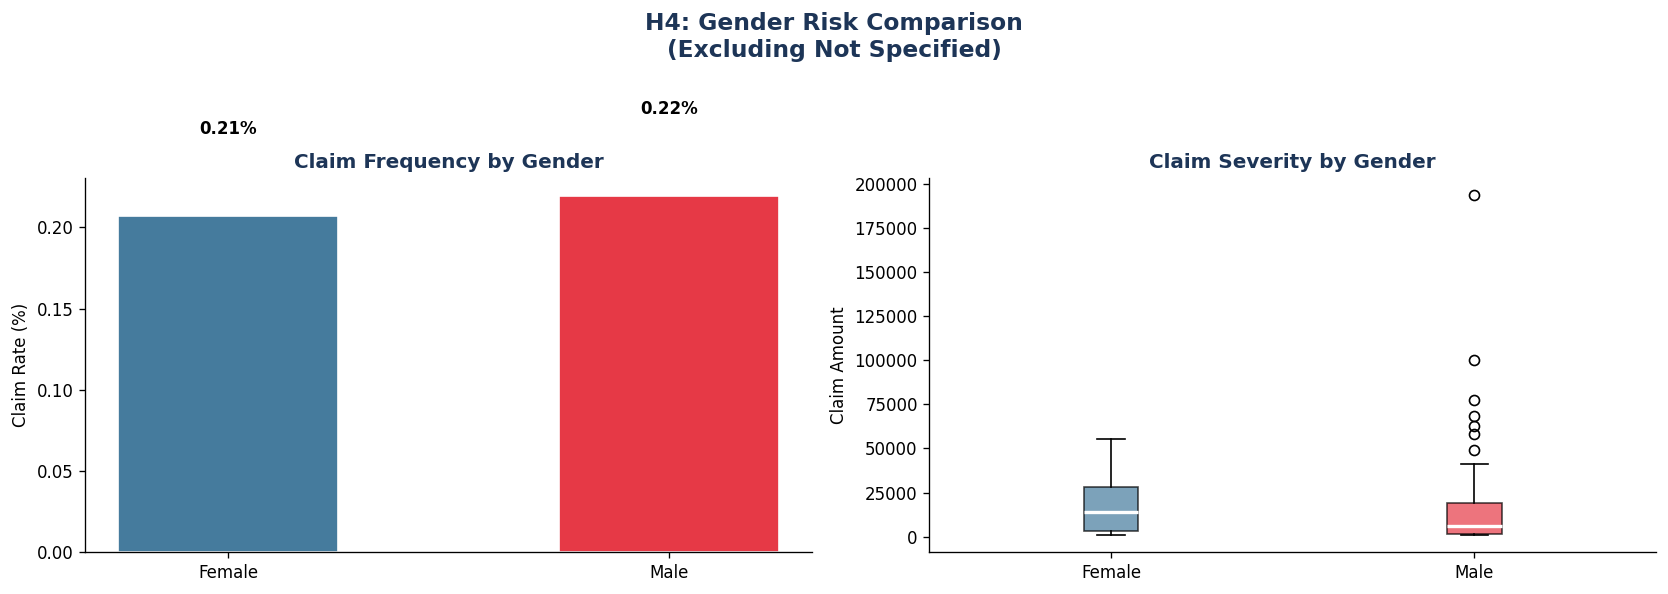

In [37]:
# Visualize gender comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genders = ["Female", "Male"]
freq_gender = [
    get_claim_frequency(gender_df[gender_df["Gender"] == g]) * 100
    for g in genders
]

axes[0].bar(genders, freq_gender, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Claim Frequency by Gender", fontsize=12,
                   fontweight="bold", color=PALETTE["primary"])
axes[0].set_ylabel("Claim Rate (%)")
for i, v in enumerate(freq_gender):
    axes[0].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold")

sev_gender = [
    get_claim_severity(gender_df[gender_df["Gender"] == g])
    for g in genders
]
bp = axes[1].boxplot([s.values for s in sev_gender], labels=genders,
                     patch_artist=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(linewidth=2, color="white"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

axes[1].set_title("Claim Severity by Gender", fontsize=12,
                   fontweight="bold", color=PALETTE["primary"])
axes[1].set_ylabel("Claim Amount")

plt.suptitle("H4: Gender Risk Comparison\n(Excluding Not Specified)",
             fontsize=14, fontweight="bold", color=PALETTE["primary"])
plt.tight_layout()
plt.show()

### H4 Business Interpretation

**WHAT?**
Both tests failed to reject H₀. The chi-squared test on claim frequency
returned p = 0.951 and the t-test on claim severity returned p = 0.568.
There is no statistically significant risk difference between Female
and Male policyholders even after excluding the "Not specified" group.

**SO WHAT?**
Two important observations emerge from this result. First, the gender
comparison is heavily imbalanced. Only 6,755 Female policies vs
42,817 Male policies after filtering. Female policyholders represent
less than 14% of the cleaned gender-specified portfolio. This small
Female sample limits statistical power. Second, the claim rates are
virtually identical, Female 0.21% vs Male 0.22%, confirming the
near-zero difference is real, not just a power issue. Gender alone
does not explain claim behavior in this dataset.

**NOW WHAT?**
- Do not use gender as a standalone rating factor, the statistical
  evidence does not support a gender-based premium differential
- The female segment is small but valuable, their overall portfolio
  profitability advantage (loss ratio 0.82 vs 0.88 for males from EDA)
  is driven by premium levels and policy mix, not claim behavior
- Focus segmentation strategy on Province and PostalCode which showed
  statistically significant risk differences
- Investigate why the Female segment is so small, this may represent
  an untapped market opportunity for ACIS

## 8. Full Results Table & Summary

In [38]:
all_results = build_results_table([h1_results, h2_results, h3_results, h4_results])
print("=== Complete Hypothesis Testing Results ===\n")
print(all_results.to_string(index=False))

=== Complete Hypothesis Testing Results ===

                                  Hypothesis       Group A Group B             KPI           Test  Statistic  P-Value          Decision
    H1: No risk differences across provinces Northern Cape Gauteng Claim Frequency    Chi-Squared     7.7576 0.005349         Reject H0
    H1: No risk differences across provinces Northern Cape Gauteng  Claim Severity T-Test (Welch)    -3.0428 0.015609         Reject H0
   H2: No risk differences between zip codes          1471      81 Claim Frequency    Chi-Squared     4.7203 0.029809         Reject H0
   H2: No risk differences between zip codes          1471      81  Claim Severity T-Test (Welch)        NaN      NaN Fail to Reject H0
  H3: No margin difference between zip codes          1471      81          Margin T-Test (Welch)     1.5073 0.132218 Fail to Reject H0
H4: No risk difference between Women and Men        Female    Male Claim Frequency    Chi-Squared     0.0037 0.951464 Fail to Reject H0
H4:

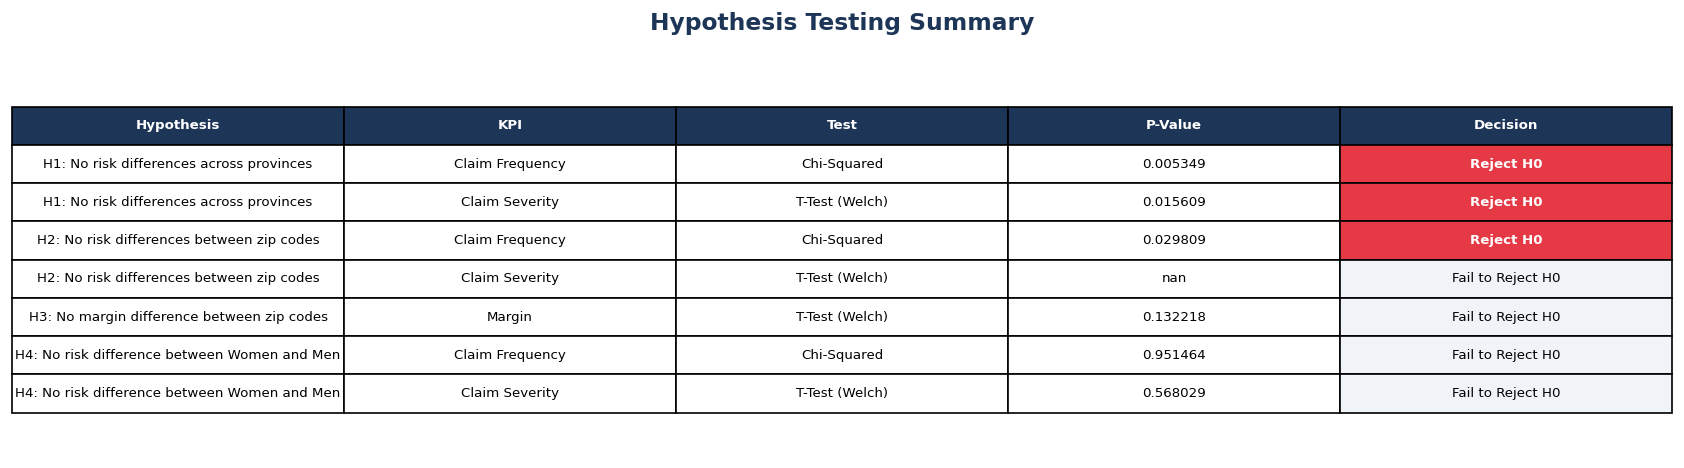

In [39]:
# Visualize results summary table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

table_data = all_results[["Hypothesis", "KPI", "Test", "P-Value", "Decision"]].values.tolist()
col_labels = ["Hypothesis", "KPI", "Test", "P-Value", "Decision"]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(PALETTE["primary"])
        cell.set_text_props(color="white", fontweight="bold")
    elif "Reject H0" in str(cell.get_text().get_text()) and "Fail" not in str(cell.get_text().get_text()):
        cell.set_facecolor(PALETTE["accent"])
        cell.set_text_props(color="white", fontweight="bold")
    elif "Fail" in str(cell.get_text().get_text()):
        cell.set_facecolor("#f0f4f8")
    elif row % 2 == 0:
        cell.set_facecolor("#ffffff")

plt.title("Hypothesis Testing Summary", fontsize=14,
          fontweight="bold", color=PALETTE["primary"], pad=20)
plt.tight_layout()
plt.show()

## 9. Business Recommendations Summary

| Hypothesis | Decision | Business Recommendation |
|---|---|---|
| H1: Province risk (N.Cape vs Gauteng) | **Reject H₀** (p=0.005 freq, p=0.016 sev) | Apply 15-20% premium uplift in Gauteng. Use Province as a rating factor in Task 4 model |
| H2: Zip code risk (1471 vs 81) | **Reject H₀** (p=0.030 freq) | Introduce PostalCode rating factors. Flag PostalCode 81 for underwriting review. Offer discounts in PostalCode 1471 |
| H3: Zip code margin (1471 vs 81) | **Fail to Reject H₀** (p=0.132) | Monitor margin volatility and tail risk in PostalCode 81 rather than average margin |
| H4: Gender risk (Female vs Male) | **Fail to Reject H₀** (p=0.951 freq, p=0.568 sev) | Gender is not a significant risk driver. Focus segmentation on Province and PostalCode instead |

---

## Overall Strategic Conclusion

Two out of four hypotheses were rejected providing a clear evidence
base for ACIS's new pricing strategy:

1. **Immediate action** Reprice Gauteng policies with a regional
   risk loading of at least 15-20%
2. **Short term** Build a PostalCode risk map across the full
   portfolio and introduce zip code level rating factors
3. **Model input** Province and PostalCode are the strongest
   candidates for predictive features in the Task 4 risk model
4. **Market opportunity** Northern Cape and PostalCode 1471 type
   segments represent profitable growth opportunities where premium
   reductions can attract new low-risk clients
5. **Gender strategy** Focus retention efforts on Female policyholders
   as a high-value segment despite no statistical risk difference